# Top-of-atmosphere signal of the atmosphere

This tutorial computes the reflectance and radiance at the top of the atmosphere (TOA) above a black
water body ($R_{rs} = 0$): the signal of the atmosphere alone, made of the light scattered by the
molecules and aerosols and of the skylight and sunlight reflected by the sea surface. It shows its
dependence on the aerosol optical thickness, the solar zenith angle and the wind speed.

With $R_{rs} = 0$, the TOA reflectance (Eq. {eq}`rtoa_rrs` of the {doc}`../methods` page) reduces to

$$
R_{toa}(\lambda) = T_g^{\downarrow}(\lambda)\, T_g^{\uparrow}(\lambda)\, R_{atm}(\lambda),
\qquad
R_{atm} = \frac{I(\lambda, \theta_s, \theta_v, \phi, \tau_a)}{\mu_0},
$$

where $I$ is the normalized radiance of the look-up table (Eq. {eq}`ratm`) and $T_g^{\downarrow}$,
$T_g^{\uparrow}$ the gaseous transmittances along the solar and viewing paths. The TOA radiance is
$L_{toa} = R_{toa}\, E_0/\pi$ (Eq. {eq}`rtoa_def`).

In [1]:
import logging

import matplotlib as mpl
import matplotlib.pyplot as plt
rc = {"font.family": "serif",
      "mathtext.fontset": "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams.update({'font.size': 18, 'axes.labelsize': 22})
# no warning when the Times New Roman font is not installed
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import numpy as np
import xarray as xr

import radcalnet_oc as radoc
# radcalnet_oc sets the root logger to INFO: show only the warnings in this tutorial
logging.getLogger().setLevel(logging.WARNING)
print(f'radcalnet_oc: {radoc.__version__}')

radcalnet_oc: 0.0.3


## Load the look-up tables

The simulations are computed at 1 nm resolution from 350 to 2500 nm.

In [2]:
central_wl = np.arange(350, 2500, 1)

lut= radoc.LUT(wl=central_wl)

## TOA reflectance and radiance

{py:meth}`LUT.lut_preparation <radcalnet_oc.lut.LUT.lut_preparation>` combines the aerosol models
with the proportions `aerosol_combination` of `config.yml` (Eq. {eq}`mixture`, see
{ref}`methods-aerosol`) and interpolates the look-up tables for the solar zenith angles (30, 45 and
60°), the nadir view and the reference aerosol optical thicknesses at 550 nm (`aot_ref`, from 0 to
0.8). The path reflectance `lut.Rdiff_lut` is $R_{atm} = I/\mu_0$, given at the wavelengths of the
look-up table and interpolated here at 1 nm.

The gaseous transmittance (here with the air mass of the full path, $1/\mu_0 + 1/\mu_v$) and the
solar irradiance are convolved with Gaussian spectral responses of 3 nm FWHM.

In [3]:
fwhm=3

szas=[30,45,60]
vza=0
lut.lut_preparation(sza=szas,vza=[vza])
szas = lut.Rdiff_lut.sza
mu0 = np.cos(np.radians(szas))
# tcwv cm into kg.m-2
tpw_cm=2.6
tcwv=tpw_cm*10 

to3_du=300 
pressure=1000

# conversion O3 du to kg.m-2
tco3=to3_du *2.14485e-5
tcno2=3e-6/100
tcch4= 1e-2

# set total transmittance values
gas_trans = radoc.GaseousTransmittance(lut.gas_lut)
gas_trans.pressure=pressure
gas_trans.gas_tc['h2o'] = tcwv
gas_trans.gas_tc['o3'] = tco3
gas_trans.gas_tc['ch4'] = tcch4
gas_trans.air_mass=1./np.cos(np.radians(szas))+1./np.cos(np.radians(vza))

gas_trans.coef_abs_scat['h2o'] = 1
gas_trans.coef_abs_scat['ch4'] = 1
Ttot=gas_trans.get_gaseous_transmittance()

# signal convolution on spectral responses
signal=Ttot
wl_signal = signal.wl.values
spectral=radoc.Spectral(central_wl,fwhm)
Tg = spectral.convolve(signal,name='Ttot').squeeze('variable', drop=True)

# get solar irradiance
solar_irr=radoc.SolarIrradiance()
signal = solar_irr.tsis
F0 = spectral.convolve(signal)*mu0

# get top-of-atmosphere reflectance or radiance
Rtoa=Tg*lut.Rdiff_lut.squeeze().interp(wl=Tg.wl, method='quadratic')
Ltoa=Rtoa*F0/np.pi

TOA reflectance from 350 to 1150 nm for each solar zenith angle; the colour gives the aerosol optical
thickness at 550 nm. The reflectance increases with the aerosol load, and is dominated by Rayleigh
scattering in the blue for clear atmospheres.

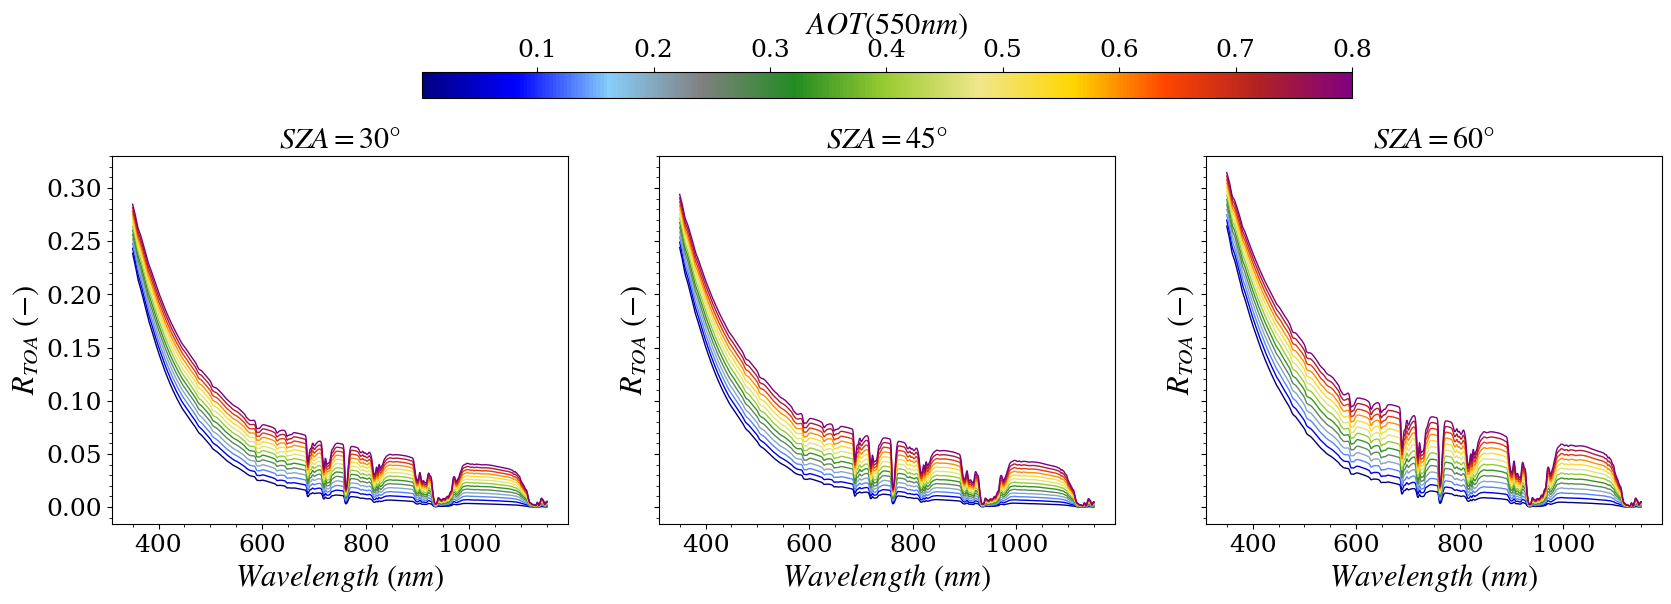

In [4]:
wl_range=slice(350,1150)
cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['navy', "blue", 'lightskyblue',
                                                     "grey",   'forestgreen','yellowgreen',
                                                     "khaki", "gold",
                                                     'orangered', "firebrick", 'purple'])
norm = mpl.colors.Normalize(vmin=0.001,vmax=0.8)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig,axs = plt.subplots(1,3,figsize=(20,6.5),sharey=True)
axs=axs.ravel()

for isza, sza in enumerate(Rtoa.sza.values):
    ax=axs[isza]
    for aot_ref in Rtoa.aot_ref.values[::2]:
        Rtoa_=Rtoa.sel(sza=sza,aot_ref=aot_ref).sel(wl=wl_range) #+ Tabs*Ttot*  np.pi * Rrs
        #Rsim.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),add_legend=False,ls=':',lw=1,ax=axs[i_])
        Rtoa_.plot(x='wl',color=cmap(norm(aot_ref)),lw=1,ax=ax)
      
    ax.set_title(r'$SZA='+str(sza)+r'\degree$')
    ax.set_ylabel(r'$R_{TOA}\ (-)$')
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.minorticks_on()

cb = fig.colorbar(sm, ax=axs[:], shrink=0.6, aspect=35, pad=0.115, location='top')
cb.set_label(r'$AOT(550nm)$', fontsize=22)

TOA radiance $L_{toa} = R_{toa}\,\mu_0 F_0/\pi$ (mW m$^{-2}$ sr$^{-1}$ nm$^{-1}$): the radiance
decreases with the solar zenith angle with the incident irradiance $\mu_0 F_0$.

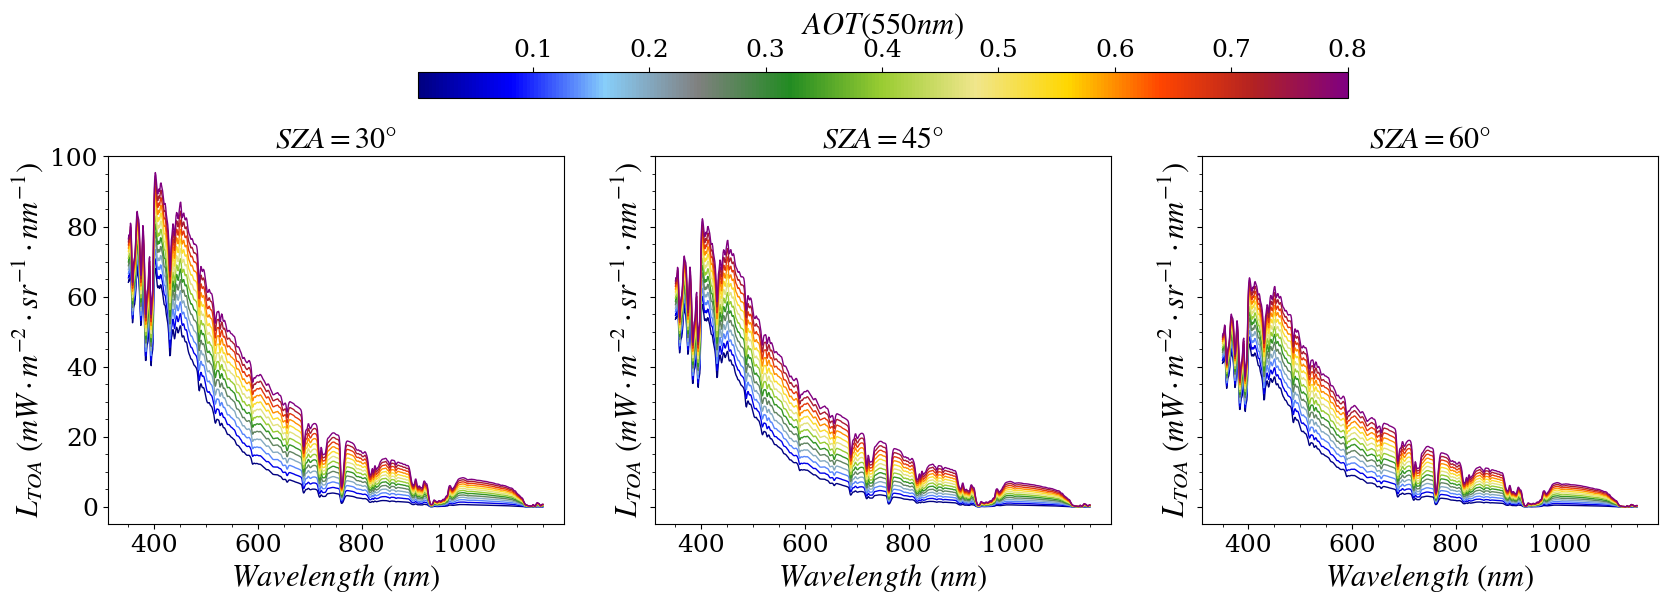

In [5]:
cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['navy', "blue", 'lightskyblue',
                                                     "grey",   'forestgreen','yellowgreen',
                                                     "khaki", "gold",
                                                     'orangered', "firebrick", 'purple'])

norm = mpl.colors.Normalize(vmin=0.001,vmax=0.8)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

sm.set_array([])
fig,axs = plt.subplots(1,3,figsize=(20,6.5),sharey=True)
axs=axs.ravel()

for isza, sza in enumerate(Rtoa.sza.values):
    ax=axs[isza]
    for aot_ref in Rtoa.aot_ref.values[::2]:
        Ltoa_=Ltoa.sel(sza=sza,aot_ref=aot_ref).sel(wl=wl_range) #+ Tabs*Ttot*  np.pi * Rrs
        #Rsim.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),add_legend=False,ls=':',lw=1,ax=axs[i_])
        Ltoa_.plot(x='wl',color=cmap(norm(aot_ref)),lw=1,ax=ax)
    ax.set_title(r'$SZA='+str(sza)+r'\degree$')
    ax.set_ylabel(r'$L_{TOA}\ (mW\cdot m^{-2}\cdot sr^{-1}\cdot nm^{-1})$')
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.minorticks_on()

cb = fig.colorbar(sm, ax=axs[:], shrink=0.6, aspect=35, pad=0.115, location='top')
cb.set_label(r'$AOT(550nm)$', fontsize=22)

## Impact of the wind speed

The radiative transfer simulations account for a rough sea surface: the skylight and sunlight
reflected by the surface depend on the wind speed. The look-up tables are simulated for wind speeds of
0.5, 2, 4, 8, 12 and 16 m s$^{-1}$ (the nearest one is used); they are prepared here for 2 and
8 m s$^{-1}$ (`wind`), with the default aerosol models.

In [6]:
lut= radoc.LUT(wl=central_wl)
lut.lut_preparation(wind=2,
                    sza=szas,
                    vza=[0],
                    azi=[0],
                    aot_refs=np.linspace(0.0, 0.8, 25))
lut2= radoc.LUT(wl=central_wl)
lut2.lut_preparation(wind=8,
                    sza=szas,
                    vza=[0],
                    azi=[0],
                    aot_refs=np.linspace(0.0, 0.8, 25))

TOA reflectance in the shortwave infrared (1250--1780 nm), where the atmospheric signal is low:
wind speed of 2 m s$^{-1}$ (solid lines) and 8 m s$^{-1}$ (dotted lines).

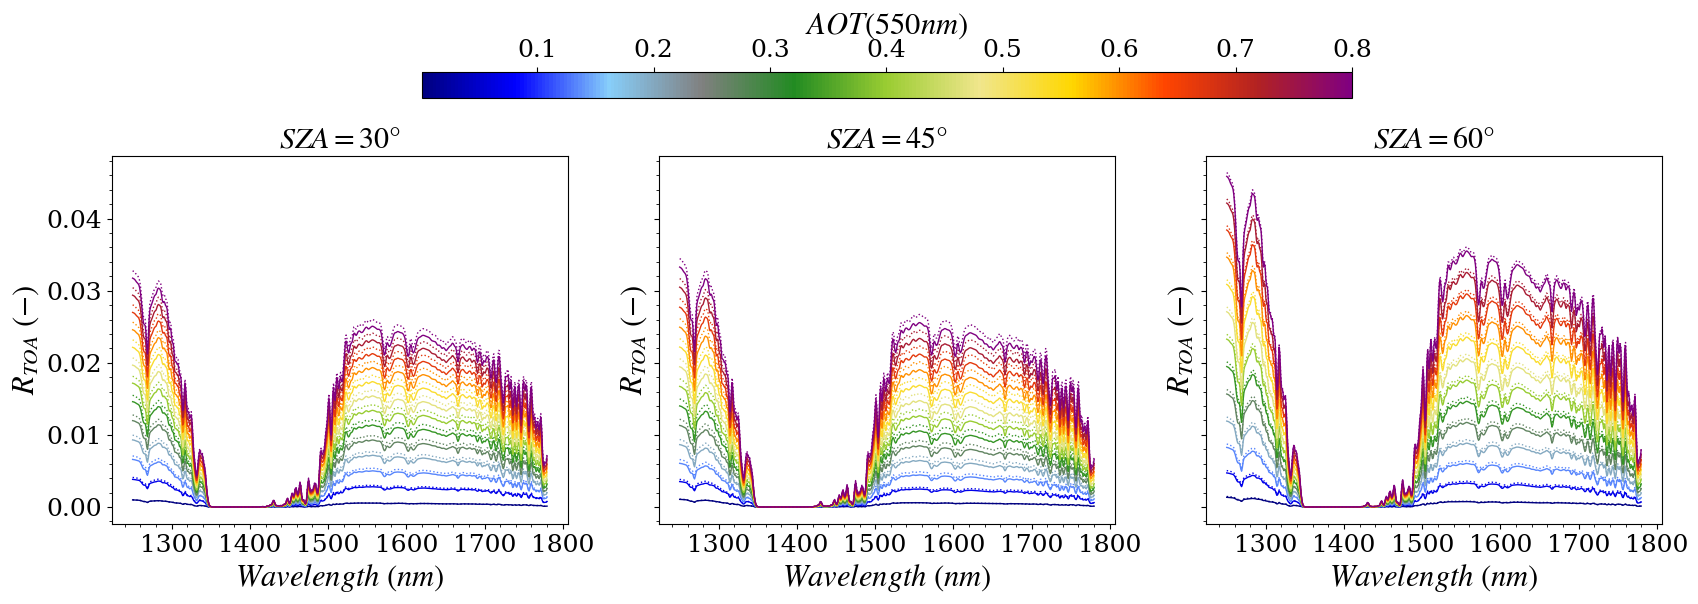

In [7]:
Rtoa=Tg*lut.Rdiff_lut.squeeze().interp(wl=Tg.wl, method='quadratic')
Rtoa2=Tg*lut2.Rdiff_lut.squeeze().interp(wl=Tg.wl, method='quadratic')
wl_range=slice(1250,1780)
cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['navy', "blue", 'lightskyblue',
                                                     "grey",   'forestgreen','yellowgreen',
                                                     "khaki", "gold",
                                                     'orangered', "firebrick", 'purple'])
norm = mpl.colors.Normalize(vmin=0.001,vmax=0.8)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig,axs = plt.subplots(1,3,figsize=(20,6.5),sharey=True)
axs=axs.ravel()

for isza, sza in enumerate(Rtoa.sza.values):
    ax=axs[isza]
    for aot_ref in Rtoa.aot_ref.values[::2]:
        Rtoa_=Rtoa.sel(sza=sza,aot_ref=aot_ref).sel(wl=wl_range) #+ Tabs*Ttot*  np.pi * Rrs
        #Rsim.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),add_legend=False,ls=':',lw=1,ax=axs[i_])
        Rtoa_.plot(x='wl',color=cmap(norm(aot_ref)),lw=1,ax=ax)
        Rtoa_=Rtoa2.sel(sza=sza,aot_ref=aot_ref).sel(wl=wl_range) #+ Tabs*Ttot*  np.pi * Rrs
       
        Rtoa_.plot(x='wl',color=cmap(norm(aot_ref)),ls=':',lw=1,ax=ax)
    ax.set_title(r'$SZA='+str(sza)+r'\degree$')
    ax.set_ylabel(r'$R_{TOA}\ (-)$')
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.minorticks_on()

cb = fig.colorbar(sm, ax=axs[:], shrink=0.6, aspect=35, pad=0.115, location='top')
cb.set_label(r'$AOT(550nm)$', fontsize=22)

Same comparison in the visible (500--780 nm).

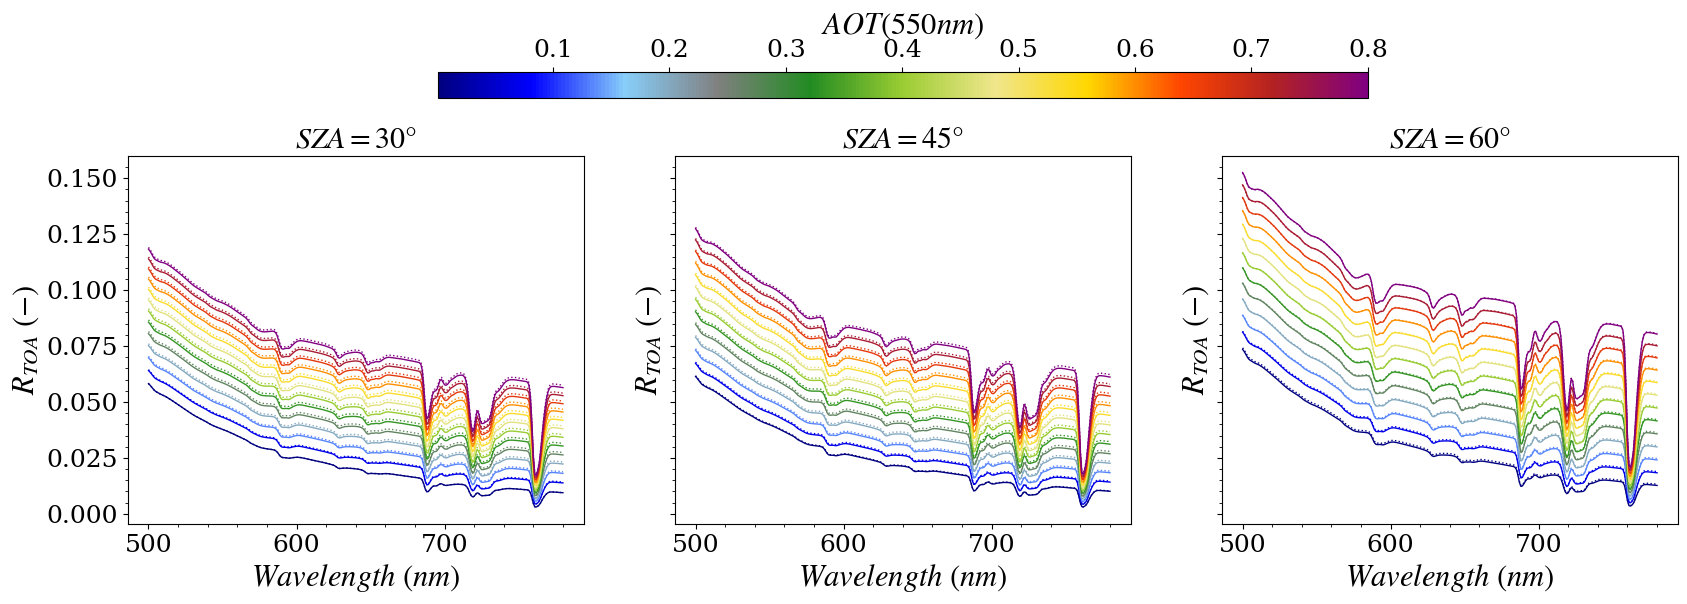

In [8]:
Rtoa=Tg*lut.Rdiff_lut.squeeze().interp(wl=Tg.wl, method='quadratic')
Rtoa2=Tg*lut2.Rdiff_lut.squeeze().interp(wl=Tg.wl, method='quadratic')
wl_range=slice(500,780)
cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['navy', "blue", 'lightskyblue',
                                                     "grey",   'forestgreen','yellowgreen',
                                                     "khaki", "gold",
                                                     'orangered', "firebrick", 'purple'])
norm = mpl.colors.Normalize(vmin=0.001,vmax=0.8)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig,axs = plt.subplots(1,3,figsize=(20,6.5),sharey=True)
axs=axs.ravel()

for isza, sza in enumerate(Rtoa.sza.values):
    ax=axs[isza]
    for aot_ref in Rtoa.aot_ref.values[::2]:
        Rtoa_=Rtoa.sel(sza=sza,aot_ref=aot_ref).sel(wl=wl_range) #+ Tabs*Ttot*  np.pi * Rrs
        #Rsim.sel(aot_ref=aot_ref).plot(x='wl',color=cmap(norm(aot_ref)),add_legend=False,ls=':',lw=1,ax=axs[i_])
        Rtoa_.plot(x='wl',color=cmap(norm(aot_ref)),lw=1,ax=ax)
        Rtoa_=Rtoa2.sel(sza=sza,aot_ref=aot_ref).sel(wl=wl_range) #+ Tabs*Ttot*  np.pi * Rrs
       
        Rtoa_.plot(x='wl',color=cmap(norm(aot_ref)),ls=':',lw=1,ax=ax)
    ax.set_title(r'$SZA='+str(sza)+r'\degree$')
    ax.set_ylabel(r'$R_{TOA}\ (-)$')
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.minorticks_on()

cb = fig.colorbar(sm, ax=axs[:], shrink=0.6, aspect=35, pad=0.115, location='top')
cb.set_label(r'$AOT(550nm)$', fontsize=22)